In [1]:
import pdblp

import pandas as pd
import numpy as np
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image

from xbbg import blp
from datetime import datetime, timedelta

from scipy.stats import percentileofscore
from scipy.stats import zscore

from datetime import datetime, timedelta
from pandas.tseries.offsets import DateOffset

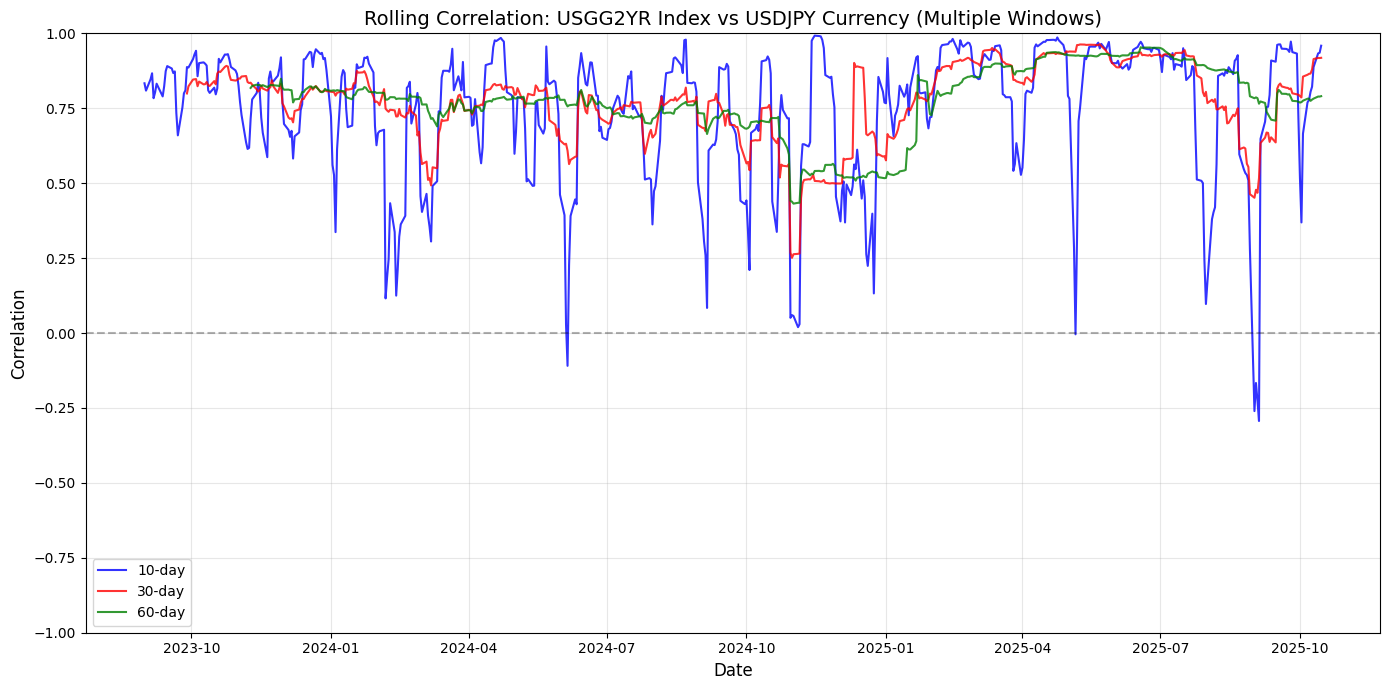

In [19]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

tickers = ['EURUSDV1W BGN Curncy', 'EURUSDV2W BGN Curncy']
years = 2
windows = [10, 30, 60]  


start_date = (datetime.today() - timedelta(days=(years * 365) + windows[-1])).strftime('%Y-%m-%d')
end_date = datetime.today().strftime('%Y-%m-%d')
prices = {}
for ticker in tickers:
    ticker_IV = f"{ticker}"
    field = "PX_LAST"
    data = blp.bdh(
        tickers=ticker_IV,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    data.columns = [ticker]
    prices[f"{ticker}"] = data[ticker]
df = pd.DataFrame(prices)
df['USGG2YR_returns'] = df['EURUSDV1W BGN Curncy'].pct_change()
df['USDJPY_returns'] = df['EURUSDV2W BGN Curncy'].pct_change()
windows = [10, 30, 60]  
colors = ['blue', 'red', 'green']
plt.figure(figsize=(14, 7))
for window, color in zip(windows, colors):
    rolling_corr = df['USGG2YR_returns'].rolling(window=window).corr(df['USDJPY_returns'])
    plt.plot(df.index, rolling_corr, label=f'{window}-day', color=color, alpha=0.8)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Rolling Correlation: USGG2YR Index vs USDJPY Currency (Multiple Windows)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()


In [2]:
# Pulls daily vols of described tenors --- over 'years'
def getDailyVols(ccy_list, tenor, years):
    start_date = (datetime.today() - timedelta(days=(years * 365))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    combined_data = pd.DataFrame()

    for ccy in ccy_list:
        ticker_IV = f"{ccy}V{tenor} BGN Curncy"
        field = "PX_LAST"
        data_IV = blp.bdh(
            tickers=ticker_IV,
            flds=field,
            start_date=start_date,
            end_date=end_date)
        data_IV.columns = [f'{ccy} Vol {tenor}']
        combined_data = pd.concat([combined_data, data_IV], axis=1)
    return combined_data


In [ ]:
# ------------ CURRENT VOL RELATIVE TO PAST ------------

def getDailyVols_ccysTenors(ccy_list, tenor_list, years):
    start_date = (datetime.today() - timedelta(days=(years * 365))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    combined_data = pd.DataFrame()

    for ccy, tenor in product(ccy_list, tenor_list):
        ticker_IV = f"{ccy}V{tenor} BGN Curncy"
        field = "PX_LAST"
        data_IV = blp.bdh(
            tickers=ticker_IV,
            flds=field,
            start_date=start_date,
            end_date=end_date
        )
        data_IV.columns = [f'{ccy} Vol {tenor}']
        combined_data = pd.concat([combined_data, data_IV], axis=1)

    return combined_data

ccy_list = ['USDJPY']
tenor_list = ['1W', '9M', '1Y']
years = 3

df = getDailyVols_ccysTenors(ccy_list, tenor_list, years)


latest_zscores = {}
for col in df.columns:
    series = df[col].dropna()
    z_scores = zscore(series)
    latest_z = pd.Series(z_scores).iloc[-1]  # use iloc for positional access
    latest_zscores[col] = latest_z

df_Zscore = pd.DataFrame([latest_zscores])

latest_percentiles = {}
for col in df.columns:
    series = df[col].dropna()
    latest_value = series.iloc[-1]
    percentile = percentileofscore(series, latest_value, kind='rank')
    latest_percentiles[col] = percentile

df_Percentile = pd.DataFrame([latest_percentiles]).round(2)
df_Percentile

,USDJPY Vol 6M,USDJPY Vol 9M,USDJPY Vol 1Y
0,10.23,13.11,17.9


In [ ]:
# Compare vol daily drop to previous EOD to EOD vol drops 
def volCompare_dropToDrops(ccy_list, date_interest, tenor, years):
    # getting days since date of interest
    date_interest = datetime.strptime(date_interest, '%Y-%m-%d')
    current_date = datetime.today()
    weekdays_passed = np.busday_count(date_interest.date(), current_date.date())  
    results = []
    for ccy in ccy_list:
        start_date = (datetime.today() - timedelta(days= (years * 365))).strftime('%Y-%m-%d')
        end_date = datetime.today().strftime('%Y-%m-%d')
        ticker_IV = f"{ccy}V{tenor} BGN Curncy"
        field = "PX_LAST"
        data_vol = blp.bdh(
            tickers=ticker_IV,
            flds=field,
            start_date=start_date,
            end_date=end_date)
        data_vol.columns = [ccy]
        vol_today = data_vol[f'{ccy}'].iloc[-1]
        vol_yesterday = data_vol[f'{ccy}'].iloc[-2]
        data_vol['DayDiff'] = data_vol[ccy].diff()
        data_vol = data_vol.dropna()
        data_vol_negative = data_vol[data_vol['DayDiff'] < 0] # Keep only that drop
        abs_day_diff = data_vol_negative['DayDiff']
        today_value = abs_day_diff.iloc[-(weekdays_passed + 1)] 
        mean_abs_day_diff = abs_day_diff.mean()
        std_abs_day_diff = abs_day_diff.std()
        ZscoreValue = (today_value - mean_abs_day_diff) / std_abs_day_diff
        ZscoreValue = abs(ZscoreValue)  # Make Z-score positive
        percentile = percentileofscore(abs_day_diff, today_value)
        percentile = 100 - percentile  # Make Percentile positive (if needed))
        results.append({
            'Currency': ccy,
            f'{tenor} Implied Vol Today': vol_today,
            f'{tenor} Impled Vol Day Change': vol_today - vol_yesterday,
            '2Y Percentile': percentile,
            '2Y Zscore': ZscoreValue
        })
    results_df = pd.DataFrame(results)
    return results_df




In [ ]:
# ccy_list = [
#     'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK',
#     'USDMXN', 'USDBRL', 'USDCNH'
# ]

ccy_list = ['USDJPY']

date_interest = '2025-1-5'

tenor = '1W'

years = 2

volCompare_dropToDrops(ccy_list, date_interest, tenor, years)


,Currency,3M Implied Vol Today,3M Impled Vol Day Change,2Y Percentile,2Y Zscore
0,CHFJPY,9.1225,0.0275,8.695652,0.954137
1,USDJPY,10.4400,0.0400,60.147601,0.012423
2,USDCHF,7.5500,-0.1200,78.388278,0.691305


In [ ]:
currency_pairs = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK',
    'USDMXN', 'USDBRL', 'USDCNH'
]
tenors = ['1M', '2W']  # Add more tenors if needed

past_days = 2


def volMoves_OpenToClose():
    start_date = (datetime.today() - timedelta(days=(2))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    open_prices = {}
    for tenor in tenors:
        for ccy in currency_pairs:
            ticker_IV = f"{ccy}V{tenor} BGN Curncy"
            field = "PX_OPEN"
            data_vol = blp.bdh(
                tickers=ticker_IV,
                flds=field,
                start_date=start_date,
                end_date=end_date)
            data_vol.columns = [ccy]
            open_prices[f"{ccy}_{tenor}"] = data_vol[ccy]
    open_df = pd.DataFrame(open_prices)
    close_prices = {}
    for tenor in tenors:
        for ccy in currency_pairs:
            ticker_IV = f"{ccy}V{tenor} BGN Curncy"
            field = "PX_LAST"
            data_vol = blp.bdh(
                tickers=ticker_IV,
                flds=field,
                start_date=start_date,
                end_date=end_date)
            data_vol.columns = [ccy]
            close_prices[f"{ccy}_{tenor}"] = data_vol[ccy]
    close_df = pd.DataFrame(close_prices)
    differences = close_df.iloc[-1] - open_df.iloc[0]
    difference_df = pd.DataFrame(differences, columns=['Difference'])
    difference_df['Currency'] = difference_df.index.str.split('_').str[0]
    difference_df['Tenor'] = difference_df.index.str.split('_').str[1]
    reshaped_df = difference_df.pivot(index='Currency', columns='Tenor', values='Difference')
    reshaped_df.columns.name = None
    reshaped_df.reset_index(inplace=True)
    reshaped_df.columns = [
        "Currency",
        "Change in 1M Implied Vol",
        "Change in 2W Implied Vol"

    ]

    column_order = ["Currency", "Change in 2W Implied Vol", "Change in 1M Implied Vol"]

    # Reorder the columns
    reshaped_df = reshaped_df[column_order]

    reshaped_df = reshaped_df.sort_values(by="Change in 2W Implied Vol", ascending=True)


    # Display the reordered DataFrame
    return reshaped_df

,Currency,Change in 2W Implied Vol,Change in 1M Implied Vol
1,EURUSD,-2.2500,-1.3425
7,USDCNH,-1.6175,-0.9075
8,USDJPY,-1.5425,-0.6850
0,AUDUSD,-1.5250,-0.6625
9,USDMXN,-1.5050,-0.5530
2,GBPUSD,-1.5050,-0.9200
6,USDCHF,-1.4400,-0.7025
10,USDNOK,-1.4175,-0.7350
3,NZDUSD,-1.4150,-0.6750
11,USDSEK,-1.3850,-0.8950


,Currency,Change in 2W Implied Vol,Change in 1M Implied Vol
1,EURUSD,-2.2450,-1.3425
7,USDCNH,-1.5975,-0.9075
8,USDJPY,-1.5400,-0.6950
2,GBPUSD,-1.5050,-0.9200
9,USDMXN,-1.4780,-0.5530
6,USDCHF,-1.4450,-0.7075
0,AUDUSD,-1.4300,-0.6375
10,USDNOK,-1.4200,-0.7325
11,USDSEK,-1.3775,-0.8925
3,NZDUSD,-1.2900,-0.6550


In [10]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image
from scipy import stats
from xbbg import blp
from datetime import datetime, timedelta
from typing import List, Optional, Tuple, Dict

from scipy.stats import percentileofscore
from itertools import permutations

In [44]:
currency_list = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 
    'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK', 'USDMXN',
    'USDBRL', 'USDCNH']

tenors = ['1M', '2M', '' '6M', '1Y']

In [45]:
base_ccy = sorted(set(currency_list))

In [46]:
base_ccy

['AUDUSD',
 'EURUSD',
 'GBPUSD',
 'NZDUSD',
 'USDBRL',
 'USDCAD',
 'USDCHF',
 'USDCNH',
 'USDJPY',
 'USDMXN',
 'USDNOK',
 'USDSEK']

In [47]:
currency_pairs = list(permutations(base_ccy, 2))

In [49]:
len(currency_pairs)

132

In [13]:
def getDailyVols_ccysTenors(ccy_list, tenor_list, years):
    start_date = (datetime.today() - timedelta(days=(years * 365))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    combined_data = pd.DataFrame()

    for ccy, tenor in product(ccy_list, tenor_list):
        ticker_IV = f"{ccy}V{tenor} BGN Curncy"
        field = "PX_LAST"
        data_IV = blp.bdh(
            tickers=ticker_IV,
            flds=field,
            start_date=start_date,
            end_date=end_date
        )
        data_IV.columns = [f'{ccy} {tenor}']
        combined_data = pd.concat([combined_data, data_IV], axis=1)

    return combined_data

ccy_list = ['USDJPY']
tenor_list = ['1W', '2W', '1M', '3M', '6M', '1Y']
years = 5

df = getDailyVols_ccysTenors(ccy_list, tenor_list, years)


In [14]:
df

,USDJPY 1W,USDJPY 2W,USDJPY 1M,USDJPY 3M,USDJPY 6M,USDJPY 1Y
2020-11-04,7.1450,6.7425,6.4975,6.5675,6.7850,6.9975
2020-11-05,7.3100,7.0300,6.5775,6.7300,6.8575,7.0475
2020-11-06,7.1050,6.9250,6.6550,6.8025,6.9525,7.0875
2020-11-09,7.1725,6.8700,6.6950,6.6025,6.6925,6.8500
2020-11-10,6.9200,6.6900,6.5250,6.5175,6.5975,6.7350
...,...,...,...,...,...,...
2025-10-28,8.9050,8.4475,8.3950,8.8450,9.0675,9.3100
2025-10-29,9.9025,8.9975,8.7550,9.0175,9.1550,9.3450
2025-10-30,7.7775,7.9200,8.0350,8.7800,9.1175,9.3325
2025-10-31,7.1400,7.4425,7.8150,8.7175,9.0650,9.3100


In [15]:
def analyze_vol_changes(df):
    daily_changes = df.diff()
    today_change = daily_changes.iloc[-1]
    lookback_periods = {
        '3M': 90,   
        '1Y': 365,  
        '3Y': 1095}
    results = []
    for col in df.columns:
        row_data = {
            'Tenor': col,
            'Today_Change': today_change[col]}
        for period_name, days in lookback_periods.items():
            historical_changes = daily_changes[col].dropna().tail(days)
            if len(historical_changes) > 0:
                percentile = stats.percentileofscore(
                    historical_changes, 
                    today_change[col], 
                    kind='rank')
                row_data[f'Percentile_{period_name}'] = percentile
            else:
                row_data[f'Percentile_{period_name}'] = np.nan
        results.append(row_data)
    results_df = pd.DataFrame(results)
    return results_df

In [16]:
analyze_vol_changes(df)

,Tenor,Today_Change,Percentile_3M,Percentile_1Y,Percentile_3Y
0,USDJPY 1W,-0.4150,27.777778,32.328767,31.141553
1,USDJPY 2W,-0.2725,26.666667,31.232877,32.237443
2,USDJPY 1M,-0.1000,44.444444,44.109589,42.237443
3,USDJPY 3M,-0.0700,38.888889,39.452055,40.000000
4,USDJPY 6M,-0.0125,55.555556,48.630137,48.630137
5,USDJPY 1Y,-0.0075,55.000000,49.863014,48.904110
